In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [92]:
ANO_ANALISE = 2021

emissao_estado = pd.read_csv(f"emissao_estado_{ANO_ANALISE}.csv")
emissao_per_capita = pd.read_csv(f"emissao_per_capita_{ANO_ANALISE}.csv")
emissao_setor = pd.read_csv(f"emissao_setor_{ANO_ANALISE}.csv")
emissao_anual = pd.read_csv("emissao_anual_brasil.csv")
df_emissoes = pd.read_csv("emissoes_co2e_gwp_ar5_1970_2021.csv")

# Objetivo do Projeto

Este projeto analisa as emissões brasileiras de gases de efeito estufa utilizando dados do SEEG e do IBGE.

Perguntas respondidas:

- Quais estados mais emitem?
- Quais estados possuem maior emissão per capita?
- Quais setores mais contribuem para as emissões?
- Como as emissões evoluíram ao longo do tempo?
- Quais são os principais insights observados?

## Fonte dos Dados

- SEEG (Sistema de Estimativas de Emissões e Remoções de Gases de Efeito Estufa)
- IBGE (População estimada dos municípios brasileiros)

# 1. Entendendo os datasets processados

Nesta etapa analisamos os datasets gerados durante o processo de preparação dos dados.

O objetivo é compreender sua estrutura antes de iniciar as análises exploratórias.

In [93]:
datasets = {
    "Emissão por Estado": emissao_estado,
    "Emissão Per Capita": emissao_per_capita,
    "Emissão por Setor": emissao_setor,
    "Emissão Anual Brasil": emissao_anual
}

for nome, df in datasets.items():
    print(f"\n{'='*60}")
    print(nome)
    print(f"{'='*60}")
    print(df.info())
    display(df.head())


Emissão por Estado
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Estado   27 non-null     object 
 1   Emissao  27 non-null     float64
dtypes: float64(1), object(1)
memory usage: 564.0+ bytes
None


,Estado,Emissao
0,PA,4.479274e+08
1,MT,2.693745e+08
2,MG,1.682337e+08
3,SP,1.567297e+08
4,AM,1.388454e+08



Emissão Per Capita
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Estado              27 non-null     object 
 1   Emissao             27 non-null     float64
 2   UF                  27 non-null     object 
 3   populacao           27 non-null     int64  
 4   emissao_per_capita  27 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ KB
None


,Estado,Emissao,UF,populacao,emissao_per_capita
0,RR,6.157727e+07,RR,634805,97.001873
1,RO,1.378898e+08,RO,1616379,85.307831
2,MT,2.693745e+08,MT,3784239,71.183268
3,PA,4.479274e+08,PA,8442962,53.053344
4,AC,4.399571e+07,AC,829780,53.020934



Emissão por Setor
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nível 1 - Setor  5 non-null      object 
 1   Emissao          5 non-null      float64
dtypes: float64(1), object(1)
memory usage: 212.0+ bytes
None


,Nível 1 - Setor,Emissao
0,Mudança de Uso da Terra e Floresta,1.188189e+09
1,Agropecuária,6.007592e+08
2,Energia,4.346073e+08
3,Processos Industriais,1.079485e+08
4,Resíduos,9.112153e+07



Emissão Anual Brasil
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      52 non-null     int64  
 1   Emissao  52 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 964.0 bytes
None


,Ano,Emissao
0,1970,3.422406e+08
1,1971,3.622887e+08
2,1972,3.827717e+08
3,1973,4.111755e+08
4,1974,4.338716e+08


# 2. Estados com maiores emissões

Antes de analisar indicadores mais sofisticados, é importante identificar quais estados apresentaram os maiores volumes absolutos de emissão em 2021.

In [94]:
top10_estados = (
    emissao_estado
    .sort_values("Emissao", ascending=False)
    .head(10)
)

top10_estados

,Estado,Emissao
0,PA,4.479274e+08
1,MT,2.693745e+08
2,MG,1.682337e+08
3,SP,1.567297e+08
4,AM,1.388454e+08
5,RO,1.378898e+08
6,MA,1.171535e+08
7,RS,1.077646e+08
8,GO,9.289627e+07
9,PR,8.628577e+07


In [95]:
def format_bilhoes(valor):
    return f"{valor/1e9:.2f} bi"

def format_milhoes(valor):
    return f"{valor/1e6:.0f} mi"

def format_percentual(valor):
    return f"{valor:.1f}%"

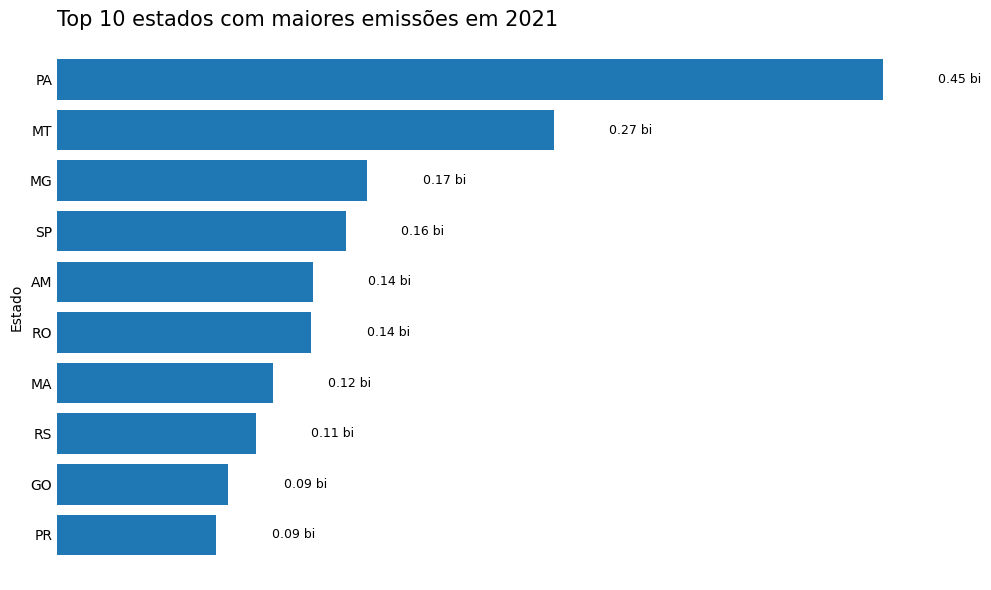

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_estados_plot = top10_estados.sort_values("Emissao", ascending=True)

bars = ax.barh(
    top10_estados_plot["Estado"],
    top10_estados_plot["Emissao"] / 1e9
)

ax.set_title(f"Top 10 estados com maiores emissões em {ANO_ANALISE}", fontsize = 15, loc='left')
ax.set_xlabel("Emissão total (bilhões tCO₂e)")
ax.set_ylabel("Estado")


for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f} bi",
        va="center",
        fontsize=9
    )

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which= 'both', length=0)

plt.tight_layout()
plt.show()

# 3. Emissões per capita

As emissões absolutas não consideram diferenças populacionais entre os estados.

Para avaliar a intensidade das emissões em relação ao tamanho da população, utilizamos o indicador de **emissões per capita**, calculado a partir da população estimada para 2021.

Essa métrica permite observar estados que apresentam volumes elevados de emissões em relação ao número de habitantes.

In [97]:
top10_per_capita = (
    emissao_per_capita
    .sort_values("emissao_per_capita", ascending=False)
    .head(10)
)

top10_per_capita

,Estado,Emissao,UF,populacao,emissao_per_capita
0,RR,6.157727e+07,RR,634805,97.001873
1,RO,1.378898e+08,RO,1616379,85.307831
2,MT,2.693745e+08,MT,3784239,71.183268
3,PA,4.479274e+08,PA,8442962,53.053344
4,AC,4.399571e+07,AC,829780,53.020934
5,TO,5.664851e+07,TO,1584306,35.756044
6,AM,1.388454e+08,AM,3952262,35.130609
7,MS,8.149935e+07,MS,2833742,28.760330
8,MA,1.171535e+08,MA,6800605,17.226916
9,GO,9.289627e+07,GO,6950976,13.364493


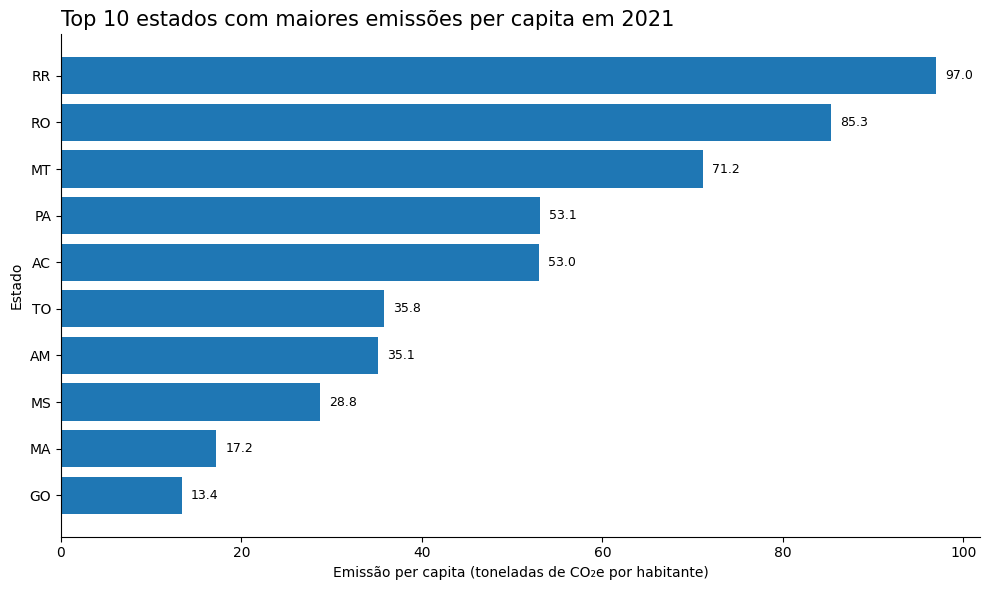

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_per_capita_plot = top10_per_capita.sort_values(
    "emissao_per_capita",
    ascending=True
)

bars = ax.barh(
    top10_per_capita_plot["Estado"],
    top10_per_capita_plot["emissao_per_capita"]
)

ax.set_title(f"Top 10 estados com maiores emissões per capita em {ANO_ANALISE}", fontsize = 15, loc='left')
ax.set_xlabel("Emissão per capita (toneladas de CO₂e por habitante)")
ax.set_ylabel("Estado")


for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=9
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Emissões absolutas × emissões per capita

Os rankings de emissões absolutas e per capita apresentam perspectivas diferentes sobre a distribuição das emissões entre os estados.

Enquanto as emissões absolutas mostram a contribuição total de cada estado, o indicador per capita relaciona esse volume ao tamanho da população.

Essa comparação permite identificar estados que possuem grande participação no total nacional e aqueles que apresentam emissões elevadas proporcionalmente ao número de habitantes.

In [99]:
ranking_abs = emissao_estado.copy()
ranking_abs["rank_abs"] = ranking_abs["Emissao"].rank(
    ascending=False,
    method="dense"
)

ranking_pc = emissao_per_capita.copy()
ranking_pc["rank_pc"] = ranking_pc["emissao_per_capita"].rank(
    ascending=False,
    method="dense"
)

comparacao = ranking_abs.merge(
    ranking_pc[["Estado", "populacao", "emissao_per_capita", "rank_pc"]],
    on="Estado"
)

comparacao = comparacao.sort_values("rank_abs")

comparacao.head(10)

,Estado,Emissao,rank_abs,populacao,emissao_per_capita,rank_pc
0,PA,4.479274e+08,1.0,8442962,53.053344,4.0
1,MT,2.693745e+08,2.0,3784239,71.183268,3.0
2,MG,1.682337e+08,3.0,20732660,8.114427,13.0
3,SP,1.567297e+08,4.0,46024937,3.405322,21.0
4,AM,1.388454e+08,5.0,3952262,35.130609,7.0
5,RO,1.378898e+08,6.0,1616379,85.307831,2.0
6,MA,1.171535e+08,7.0,6800605,17.226916,9.0
7,RS,1.077646e+08,8.0,11088065,9.718976,11.0
8,GO,9.289627e+07,9.0,6950976,13.364493,10.0
9,PR,8.628577e+07,10.0,11835379,7.290495,15.0


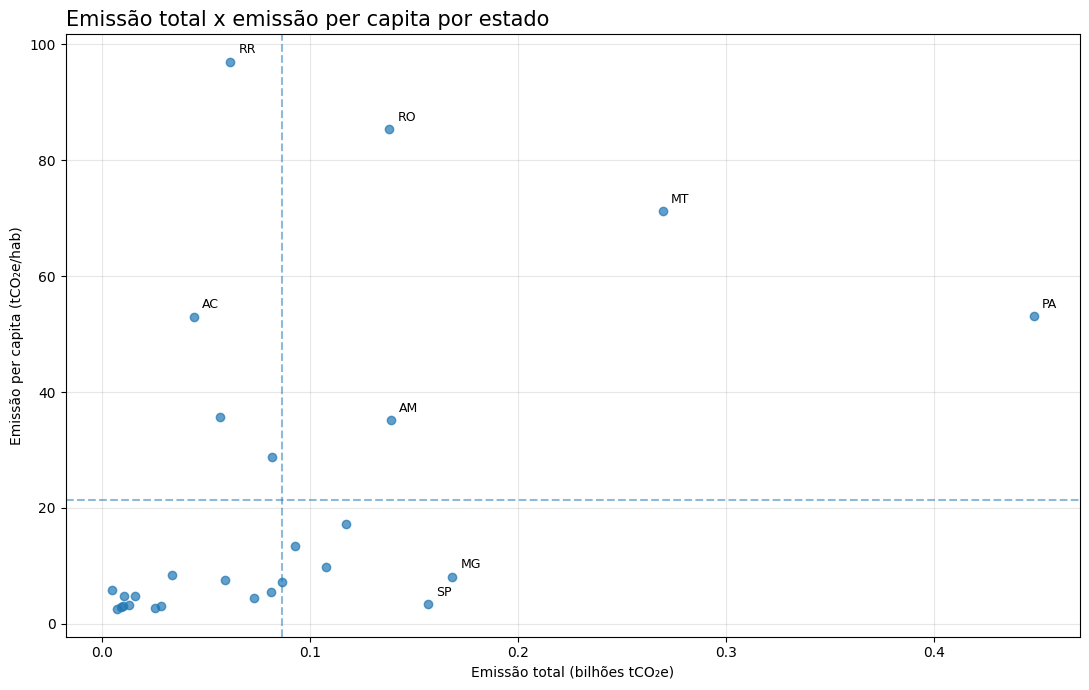

In [100]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    comparacao["Emissao"] / 1e9,
    comparacao["emissao_per_capita"],
    alpha=0.7
)

media_emissao = comparacao["Emissao"].mean() / 1e9
media_per_capita = comparacao["emissao_per_capita"].mean()

ax.axvline(media_emissao, linestyle="--", alpha=0.5)
ax.axhline(media_per_capita, linestyle="--", alpha=0.5)

estados_destaque = (
    set(comparacao.nlargest(5, "Emissao")["Estado"])
    | set(comparacao.nlargest(5, "emissao_per_capita")["Estado"])
)

for _, row in comparacao.iterrows():
    if row["Estado"] in estados_destaque:
        ax.annotate(
            row["Estado"],
            (row["Emissao"] / 1e9, row["emissao_per_capita"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title("Emissão total x emissão per capita por estado", fontsize = 15, loc='left')
ax.set_xlabel("Emissão total (bilhões tCO₂e)")
ax.set_ylabel("Emissão per capita (tCO₂e/hab)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A comparação entre emissões absolutas e emissões per capita revela diferenças importantes.

Estados com grandes populações tendem a aparecer entre os maiores emissores totais, mas não necessariamente lideram em emissão por habitante. Já estados menos populosos podem apresentar emissões per capita elevadas, indicando maior intensidade de emissões em relação ao tamanho da população.

Essa diferença reforça a importância de analisar os dois indicadores em conjunto.

# 5. Emissões por setor econômico

Após identificar os estados com maiores emissões absolutas e per capita, analisamos quais setores econômicos mais contribuem para as emissões brasileiras.

Essa análise ajuda a compreender quais atividades possuem maior impacto na composição das emissões nacionais.

In [101]:
emissao_setor.sort_values(
    "Emissao",
    ascending=False
)

,Nível 1 - Setor,Emissao
0,Mudança de Uso da Terra e Floresta,1.188189e+09
1,Agropecuária,6.007592e+08
2,Energia,4.346073e+08
3,Processos Industriais,1.079485e+08
4,Resíduos,9.112153e+07


In [102]:
setores_percentual = emissao_setor.copy()

total = setores_percentual["Emissao"].sum()

setores_percentual["Participacao (%)"] = (
    setores_percentual["Emissao"] / total * 100
)

setores_percentual.sort_values(
    "Participacao (%)",
    ascending=False
)

,Nível 1 - Setor,Emissao,Participacao (%)
0,Mudança de Uso da Terra e Floresta,1.188189e+09,49.045500
1,Agropecuária,6.007592e+08,24.797862
2,Energia,4.346073e+08,17.939518
3,Processos Industriais,1.079485e+08,4.455848
4,Resíduos,9.112153e+07,3.761272


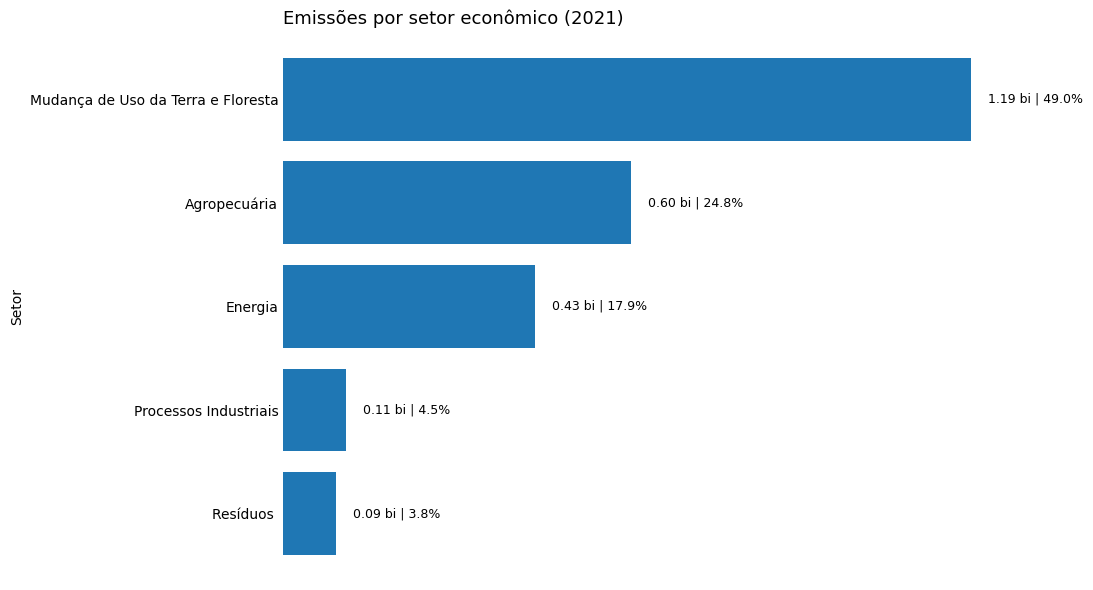

In [103]:
setores_percentual = emissao_setor.copy()

total_emissoes_setores = setores_percentual["Emissao"].sum()

setores_percentual["Participacao (%)"] = (
    setores_percentual["Emissao"] / total_emissoes_setores * 100
)

setores_plot = setores_percentual.sort_values("Emissao", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    setores_plot["Nível 1 - Setor"],
    setores_plot["Emissao"] / 1e9
)

ax.set_title(f"Emissões por setor econômico ({ANO_ANALISE})", fontsize = 13, loc = 'left')
ax.set_xlabel("Emissão (bilhões tCO₂e)")
ax.set_ylabel("Setor")


for bar, percentual in zip(bars, setores_plot["Participacao (%)"]):
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f} bi | {percentual:.1f}%",
        va="center",
        fontsize=9
    )

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which= 'both', length=0)

plt.tight_layout()
plt.show()

In [104]:
top3_setores = setores_percentual.sort_values(
    "Emissao",
    ascending=False
).head(3)

participacao_top3 = top3_setores["Participacao (%)"].sum()

print(
    f"Os 3 setores mais emissores concentram "
    f"{participacao_top3:.1f}% das emissões brasileiras em {ANO_ANALISE}."
)

Os 3 setores mais emissores concentram 91.8% das emissões brasileiras em 2021.


## Principais conclusões

A distribuição das emissões brasileiras apresenta forte concentração setorial.

Em 2021, **Mudança de Uso da Terra e Floresta (49,0%)**, **Agropecuária (24,8%)** e **Energia (17,9%)** foram responsáveis conjuntamente por aproximadamente **91,8% das emissões nacionais**.

Esse resultado evidencia que a maior parte das emissões brasileiras está concentrada em apenas três dos setores analisados.

# 6. Evolução das emissões brasileiras ao longo do tempo

Até aqui analisamos a distribuição das emissões em 2021.

Nesta etapa, observamos a evolução histórica das emissões brasileiras entre 1970 e 2021, buscando identificar tendências e períodos de crescimento ou redução.

É importante considerar, entretanto, que a cobertura temporal dos setores não é uniforme. Segundo a documentação do SEEG, os dados de Mudança de Uso da Terra e Floresta estão disponíveis apenas a partir de 1990. Dessa forma, os totais nacionais anteriores a 1990 não são diretamente comparáveis aos anos seguintes.


In [105]:
emissao_anual.head()

,Ano,Emissao
0,1970,3.422406e+08
1,1971,3.622887e+08
2,1972,3.827717e+08
3,1973,4.111755e+08
4,1974,4.338716e+08


In [106]:
emissao_anual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      52 non-null     int64  
 1   Emissao  52 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 964.0 bytes


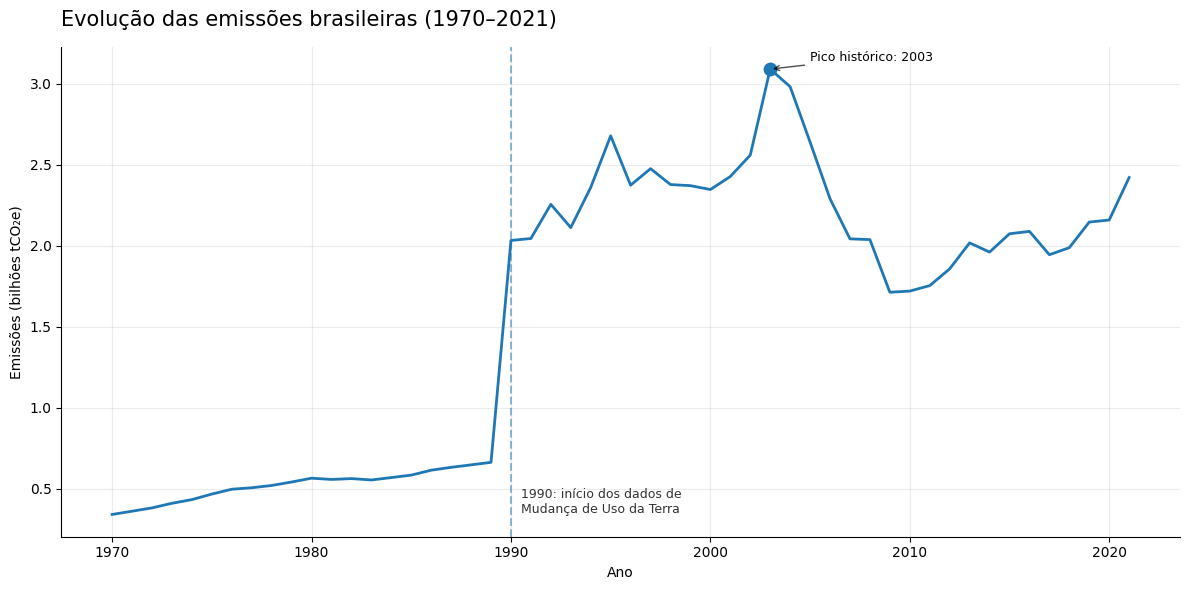

In [107]:
ano_pico = emissao_anual.loc[
    emissao_anual["Emissao"].idxmax()
]

ano_pico_valor = int(ano_pico["Ano"])
emissao_pico = ano_pico["Emissao"] / 1e9

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    emissao_anual["Ano"],
    emissao_anual["Emissao"] / 1e9,
    linewidth=2
)

# Marca o início da série completa
ax.axvline(
    1990,
    linestyle="--",
    alpha=0.5
)

ax.text(
    1990 + 0.5,
    0.35,
    "1990: início dos dados de\nMudança de Uso da Terra",
    fontsize=9,
    alpha=0.8
)

# Destaque do pico histórico
ax.scatter(
    ano_pico_valor,
    emissao_pico,
    s=80
)

ax.annotate(
    f"Pico histórico: {ano_pico_valor}",
    xy=(ano_pico_valor, emissao_pico),
    xytext=(ano_pico_valor + 2, emissao_pico + 0.05),
    arrowprops=dict(arrowstyle="->", alpha=0.7),
    fontsize=9
)

ax.set_title(
    "Evolução das emissões brasileiras (1970–2021)",
    pad=15,
    loc="left",
    fontsize=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("Emissões (bilhões tCO₂e)")
ax.grid(True, alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [108]:
primeiro_ano_comparavel = emissao_anual.loc[
    emissao_anual["Ano"] == 1990,
    "Emissao"
].iloc[0]

ultimo_ano = emissao_anual.loc[
    emissao_anual["Ano"] == 2021,
    "Emissao"
].iloc[0]

crescimento = (
    (ultimo_ano - primeiro_ano_comparavel)
    / primeiro_ano_comparavel
) * 100

print(
    f"Variação acumulada entre 1990 e 2021: {crescimento:.2f}%"
)

Variação acumulada entre 1990 e 2021: 19.11%


In [109]:
emissao_anual["Variacao (%)"] = (
    emissao_anual["Emissao"]
    .pct_change()
    * 100
)

# A variação de 1990 não é comparável devido à inclusão
# de Mudança de Uso da Terra e Floresta a partir desse ano
emissao_anual.loc[
    emissao_anual["Ano"] == 1990,
    "Variacao (%)"
] = np.nan

emissao_anual.head()

,Ano,Emissao,Variacao (%)
0,1970,3.422406e+08,NaN
1,1971,3.622887e+08,5.857896
2,1972,3.827717e+08,5.653794
3,1973,4.111755e+08,7.420551
4,1974,4.338716e+08,5.519810


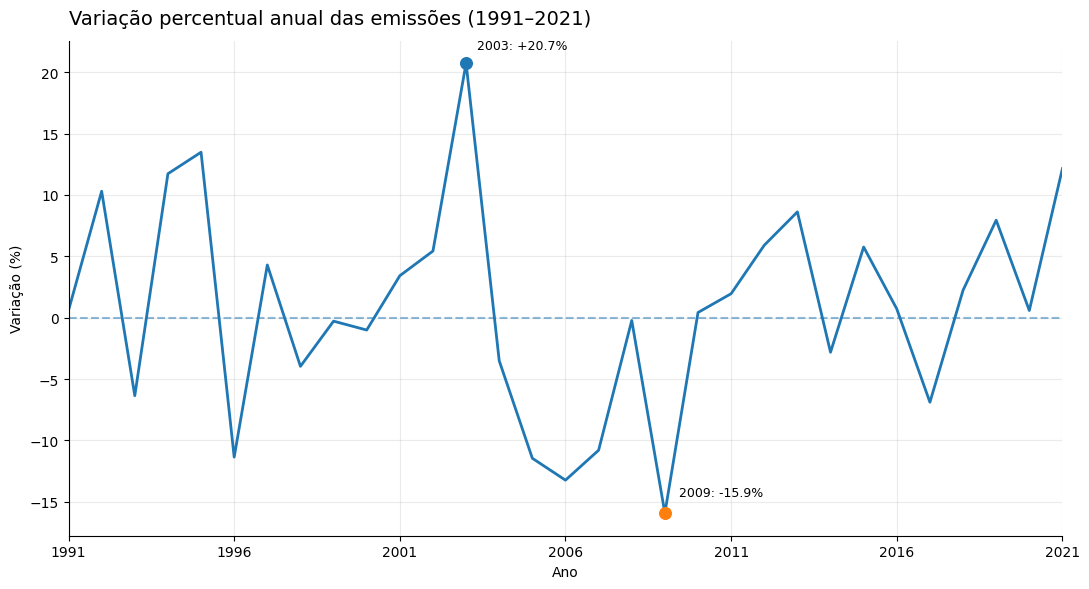

In [118]:
# Considera apenas as variações da série diretamente comparável
variacao_comparavel = emissao_anual[
    emissao_anual["Ano"] >= 1991
].copy()

maior_alta = variacao_comparavel.loc[
    variacao_comparavel["Variacao (%)"].idxmax()
]

maior_queda = variacao_comparavel.loc[
    variacao_comparavel["Variacao (%)"].idxmin()
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    variacao_comparavel["Ano"],
    variacao_comparavel["Variacao (%)"],
    linewidth=2
)

# Linha de referência
ax.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

# Destaque da maior alta
ax.scatter(
    maior_alta["Ano"],
    maior_alta["Variacao (%)"],
    s=70,
    zorder=3
)

ax.annotate(
    f'{int(maior_alta["Ano"])}: +{maior_alta["Variacao (%)"]:.1f}%',
    xy=(
        maior_alta["Ano"],
        maior_alta["Variacao (%)"]
    ),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=9
)

# Destaque da maior queda
ax.scatter(
    maior_queda["Ano"],
    maior_queda["Variacao (%)"],
    s=70,
    zorder=3
)

ax.annotate(
    f'{int(maior_queda["Ano"])}: {maior_queda["Variacao (%)"]:.1f}%',
    xy=(
        maior_queda["Ano"],
        maior_queda["Variacao (%)"]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=9,
    ha="left",
    va="bottom"
)

ax.set_title(
    "Variação percentual anual das emissões (1991–2021)",
    loc="left",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Ano")
ax.set_ylabel("Variação (%)")

ax.set_xlim(1991, 2021)
ax.set_xticks(range(1991, 2022, 5))

ax.grid(True, alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [111]:
ano_pico = emissao_anual.loc[
    emissao_anual["Emissao"].idxmax()
]

print(
    f"""
Ano de maior emissão: {int(ano_pico['Ano'])}

Emissão:
{ano_pico['Emissao']/1e9:.2f} bilhões tCO₂e

Variação em relação ao ano anterior:
{ano_pico['Variacao (%)']:.2f}%
"""
)


Ano de maior emissão: 2003

Emissão:
3.09 bilhões tCO₂e

Variação em relação ao ano anterior:
20.75%



In [112]:
maior_aumento = emissao_anual.loc[
    emissao_anual["Variacao (%)"].idxmax()
]

maior_queda = emissao_anual.loc[
    emissao_anual["Variacao (%)"].idxmin()
]

print(
    f"Maior aumento: {int(maior_aumento['Ano'])} "
    f"({maior_aumento['Variacao (%)']:.2f}%)"
)

print(
    f"Maior queda: {int(maior_queda['Ano'])} "
    f"({maior_queda['Variacao (%)']:.2f}%)"
)

Maior aumento: 2003 (20.75%)
Maior queda: 2009 (-15.94%)


A partir de 1991, quando as variações anuais passam a ser calculadas sobre anos com cobertura setorial comparável, observa-se uma trajetória marcada por oscilações relevantes.

A **maior alta anual ocorreu em 2003**, enquanto a **maior redução ocorreu em 2009**.

Essas oscilações indicam que a trajetória das emissões brasile

### Investigação da quebra da série em 1990

A visualização histórica mostra uma mudança expressiva no total de emissões entre 1989 e 1990.

Entretanto, a documentação do SEEG indica que o setor de **Mudança de Uso da Terra e Floresta** possui dados disponíveis apenas a partir de 1990. Portanto, o aumento observado nesse período pode estar relacionado a uma mudança na cobertura da base, e não necessariamente a um crescimento real das emissões brasileiras.

Para verificar essa hipótese, as emissões de 1989 e 1990 foram decompostas por setor.

In [113]:
comparacao_8990 = (
    df_emissoes[
        df_emissoes["Ano"].isin([1989, 1990])
    ]
    .groupby(
        ["Nível 1 - Setor", "Ano"],
        as_index=False
    )["Emissao"]
    .sum()
)

comparacao_8990

,Nível 1 - Setor,Ano,Emissao
0,Agropecuária,1989,3.854730e+08
1,Agropecuária,1990,3.908429e+08
2,Energia,1989,1.960147e+08
3,Energia,1990,1.925912e+08
4,Mudança de Uso da Terra e Floresta,1989,0.000000e+00
5,Mudança de Uso da Terra e Floresta,1990,1.368971e+09
6,Processos Industriais,1989,5.561851e+07
7,Processos Industriais,1990,5.147751e+07
8,Resíduos,1989,2.689531e+07
9,Resíduos,1990,3.006119e+07


In [114]:
comparacao_setorial = (
    comparacao_8990
    .pivot(
        index="Nível 1 - Setor",
        columns="Ano",
        values="Emissao"
    )
    .fillna(0)
)

comparacao_setorial["Diferença"] = (
    comparacao_setorial[1990]
    - comparacao_setorial[1989]
)

comparacao_setorial = (
    comparacao_setorial
    .sort_values("Diferença", ascending=False)
)

comparacao_setorial

Ano,1989,1990,Diferença
Nível 1 - Setor,,,
Mudança de Uso da Terra e Floresta,0.000000e+00,1.368971e+09,1.368971e+09
Agropecuária,3.854730e+08,3.908429e+08,5.369851e+06
Resíduos,2.689531e+07,3.006119e+07,3.165881e+06
Energia,1.960147e+08,1.925912e+08,-3.423529e+06
Processos Industriais,5.561851e+07,5.147751e+07,-4.140994e+06


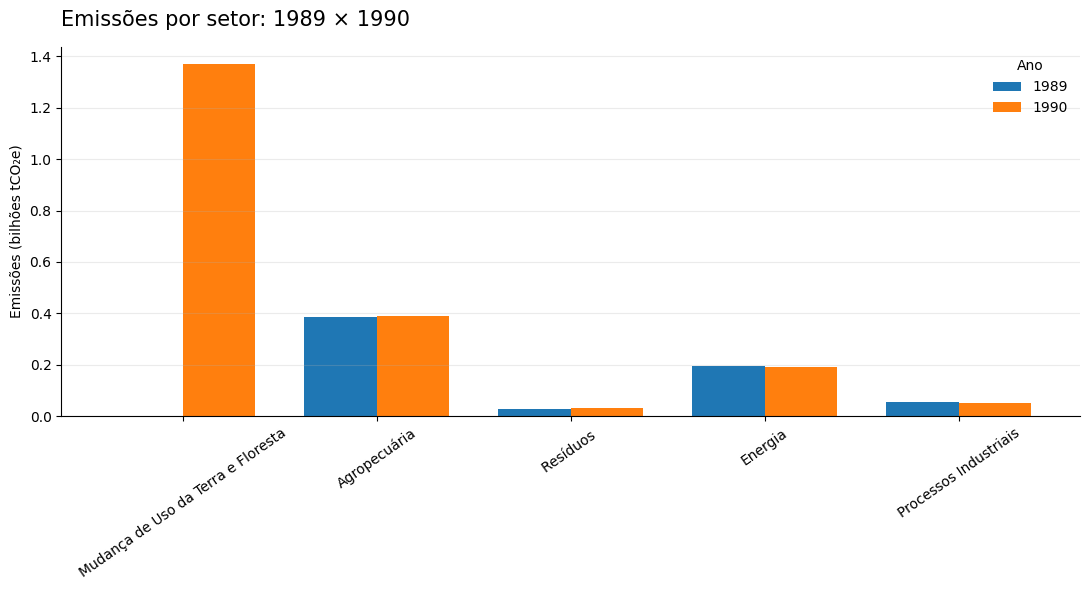

In [115]:
comparacao_grafico = (
    comparacao_setorial[[1989, 1990]]
    / 1e9
)

ax = comparacao_grafico.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

ax.set_title(
    "Emissões por setor: 1989 × 1990",
    loc="left",
    fontsize=15,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Emissões (bilhões tCO₂e)")

ax.tick_params(
    axis="x",
    rotation=35
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    title="Ano",
    frameon=False
)

plt.tight_layout()
plt.show()

In [116]:
diferenca_total = (
    emissao_anual.loc[
        emissao_anual["Ano"] == 1990,
        "Emissao"
    ].iloc[0]
    -
    emissao_anual.loc[
        emissao_anual["Ano"] == 1989,
        "Emissao"
    ].iloc[0]
)

diferenca_uso_terra = comparacao_setorial.loc[
    "Mudança de Uso da Terra e Floresta",
    "Diferença"
]

contribuicao_uso_terra = (
    diferenca_uso_terra
    / diferenca_total
) * 100

print(
    f"""
Diferença total entre 1989 e 1990:
{diferenca_total / 1e9:.2f} bilhão tCO₂e

Diferença em Mudança de Uso da Terra e Floresta:
{diferenca_uso_terra / 1e9:.2f} bilhão tCO₂e

Participação do setor na diferença:
{contribuicao_uso_terra:.2f}%
"""
)


Diferença total entre 1989 e 1990:
1.37 bilhão tCO₂e

Diferença em Mudança de Uso da Terra e Floresta:
1.37 bilhão tCO₂e

Participação do setor na diferença:
99.93%



A decomposição setorial confirma que a mudança observada em 1990 está praticamente toda associada à entrada do setor de **Mudança de Uso da Terra e Floresta** na série.

O setor não apresenta emissões registradas antes de 1990 na base utilizada e passa a representar aproximadamente **1,37 bilhão de tCO₂e** naquele ano, explicando cerca de **99,9% da diferença observada entre 1989 e 1990**.

Portanto, o crescimento superior a 200% inicialmente identificado não deve ser interpretado como um aumento real dessa magnitude nas emissões brasileiras. Trata-se principalmente de uma **quebra de comparabilidade temporal causada pela diferença de cobertura entre os setores**.

Por esse motivo, as análises de evolução das emissões totais passam a considerar **1990 como o início da série diretamente comparável**.

## Principais marcos da série histórica

Considerando as diferenças de cobertura temporal da base, a análise da evolução das emissões permite destacar alguns pontos:

- **1990:** início da série diretamente comparável das emissões totais, devido à inclusão de Mudança de Uso da Terra e Floresta.
- **2003:** maior volume de emissões registrado no período analisado e maior crescimento percentual anual da série comparável.
- **2009:** maior redução percentual anual observada entre 1991 e 2021.
- **2021:** encerramento da série analisada, apresentando crescimento em relação ao ano anterior.

# 7. Principais Insights

A análise exploratória permitiu identificar padrões relevantes sobre a distribuição e evolução das emissões brasileiras de gases de efeito estufa.

Os principais achados estão resumidos abaixo.

### - Emissão absoluta não representa necessariamente maior impacto por habitante

Estados com grandes populações aparecem entre os maiores emissores absolutos, porém nem sempre lideram o ranking de emissões per capita.

A comparação dos dois indicadores mostrou que estados menos populosos podem apresentar intensidade de emissões significativamente maior quando o fator populacional é considerado.

### - Os três principais setores concentram 91,8% das emissões nacionais

Em 2021, **Mudança de Uso da Terra e Floresta (49,0%)**, **Agropecuária (24,8%)** e **Energia (17,9%)** concentraram aproximadamente **91,8% das emissões brasileiras**.

A distribuição demonstra uma forte concentração das emissões nacionais em poucos setores, com destaque para Mudança de Uso da Terra e Floresta, responsável por quase metade do total analisado.

### - A cobertura temporal dos dados afeta a interpretação da série histórica

A análise inicialmente identificou um crescimento superior a 200% das emissões entre 1989 e 1990.

Entretanto, a decomposição por setor mostrou que aproximadamente **99,9% dessa diferença** está associada à entrada de **Mudança de Uso da Terra e Floresta**, cujos dados estão disponíveis apenas a partir de 1990.

Esse resultado evidencia a importância de verificar a cobertura e a comparabilidade dos dados antes de interpretar variações históricas. Por esse motivo, **1990 foi adotado como início da série diretamente comparável para análises das emissões totais**.

### - Pico histórico registrado em 2003

O maior volume de emissões da série foi observado em 2003, quando o Brasil atingiu aproximadamente 3,09 bilhões de toneladas de CO₂ equivalente.

Após esse período, observou-se uma redução significativa nas emissões até o final da década.

### - Tendência recente de recuperação das emissões

Após o período de queda observado entre 2004 e 2009, as emissões voltaram a crescer gradualmente.

Em 2021, os níveis observados permanecem abaixo do pico histórico, mas acima dos valores registrados no final da década de 2000.

# 8. Próximos Passos

Este projeto representa uma análise exploratória inicial da base de emissões do SEEG.

Possíveis evoluções futuras incluem:

- Construção de dashboards interativos em Power BI;
- Integração dos dados em banco SQL para consultas analíticas;
- Análise geoespacial das emissões por estado;
- Desenvolvimento de modelos preditivos para projeção de emissões futuras;
- Cruzamento com indicadores socioeconômicos e ambientais do IBGE;
- Construção de aplicações interativas utilizando Streamlit.